In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the sgp set you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('Propotion of 1s: ', np.round(sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0],2))
sgp_df_SR.head() 

(6788, 3)
Propotion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112
3,0.0,0.0,0.994921
4,0.0,0.0,0.978682


In [3]:
sgp_df_MCD = pickle.load(open('sgp_set_cnn_MCD','rb')) 
print(sgp_df_MCD.shape)
print('Propotion of 1s: ', np.round(sgp_df_MCD.y_true.sum()/sgp_df_MCD.shape[0],2))
sgp_df_MCD.head()

(6788, 3)
Propotion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536
3,0.0,0.0,-0.000046
4,0.0,0.0,-0.001196


In [4]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)]
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):]

train_set_MCD = sgp_df_MCD.iloc[:3*int(len(sgp_df_MCD)/4)]
train_set_MCD = train_set_MCD.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_MCD = sgp_df_MCD.iloc[3*int(len(sgp_df_MCD)/4):]

In [5]:
delta = 0.005
greedy_search_steps_num = 100 # increase number of search steps for more precise metrics bounds
num_targets = 100

Plot lines configuration 

In [6]:
lines_list_1_SR = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                   {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                   {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#e5be12','style':'--'},
                   {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#27e21d','style':'-'}]
lines_list_1_MCD = [{'kappa':'MCD','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                    {'kappa':'MCD','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                    {'kappa':'MCD','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#e5be12','style':'--'},
                    {'kappa':'MCD','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#27e21d','style':'-'}]
lines_list_2 = [{'kappa':'SR','name':'Guaranteed (SR)', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':"#053379",'style':'-'},
                {'kappa':'SR','name':'On test set (SR)', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#053379','style':'--'},
                {'kappa':'MCD','name':'Guaranteed (MCD)', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':"#41e70e",'style':'-'},
                {'kappa':'MCD','name':'On test set (MCD)', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#41e70e','style':'--'}]

## <font color = 'yellow'> 1. __0/1 risk__ 
Dichotomy search for upper bound

In [7]:
metric_targets = np.linspace(0.02,0.13,num=num_targets)

In [8]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR, k=int(np.log2(train_set_SR.shape[0])),
                         delta=delta, metric_targets=metric_targets, mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD, k=int(np.log2(train_set_MCD.shape[0])),
                         delta=delta, metric_targets=metric_targets, mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

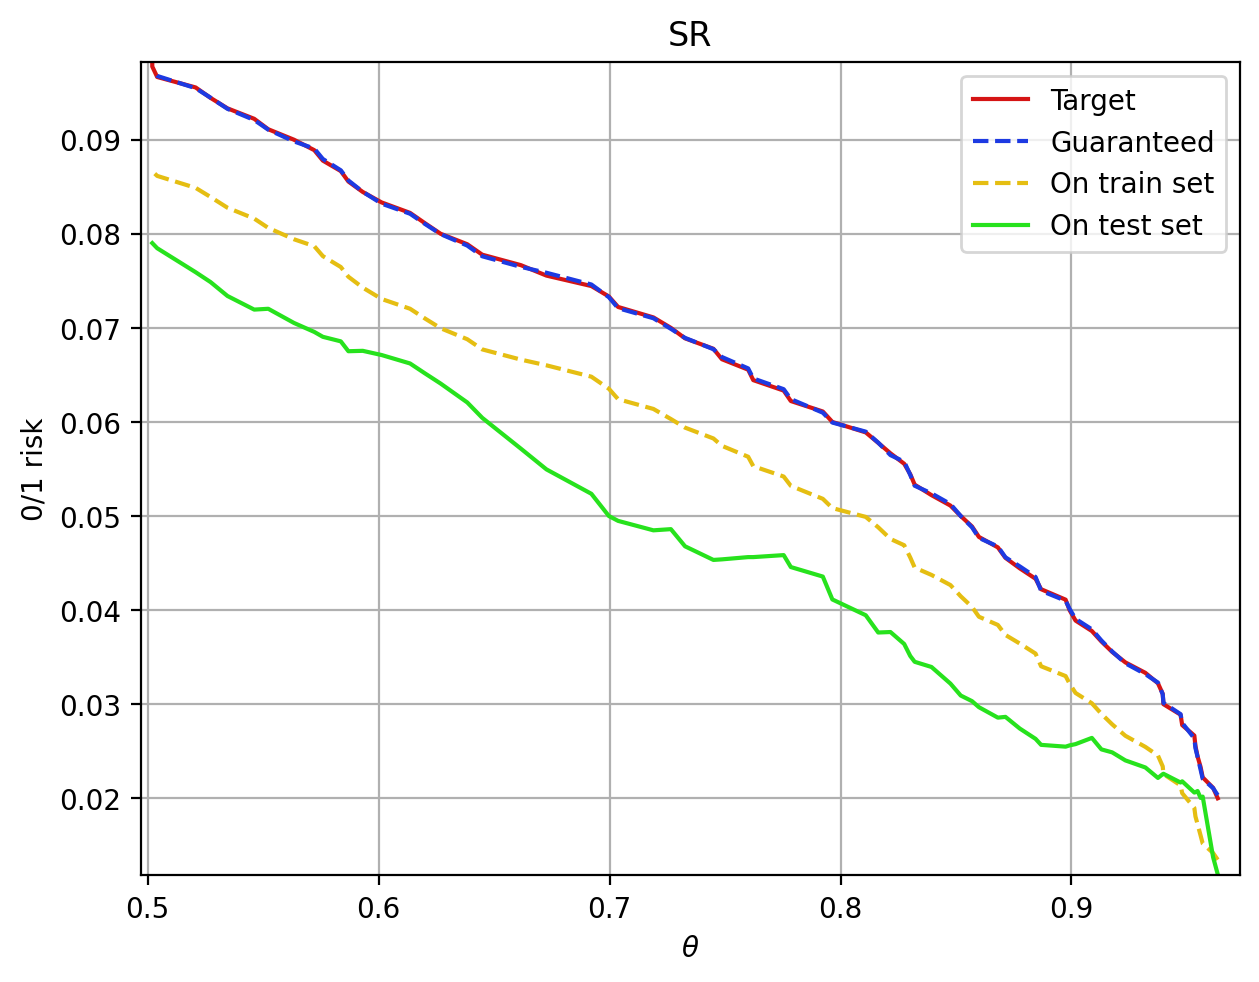

In [9]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

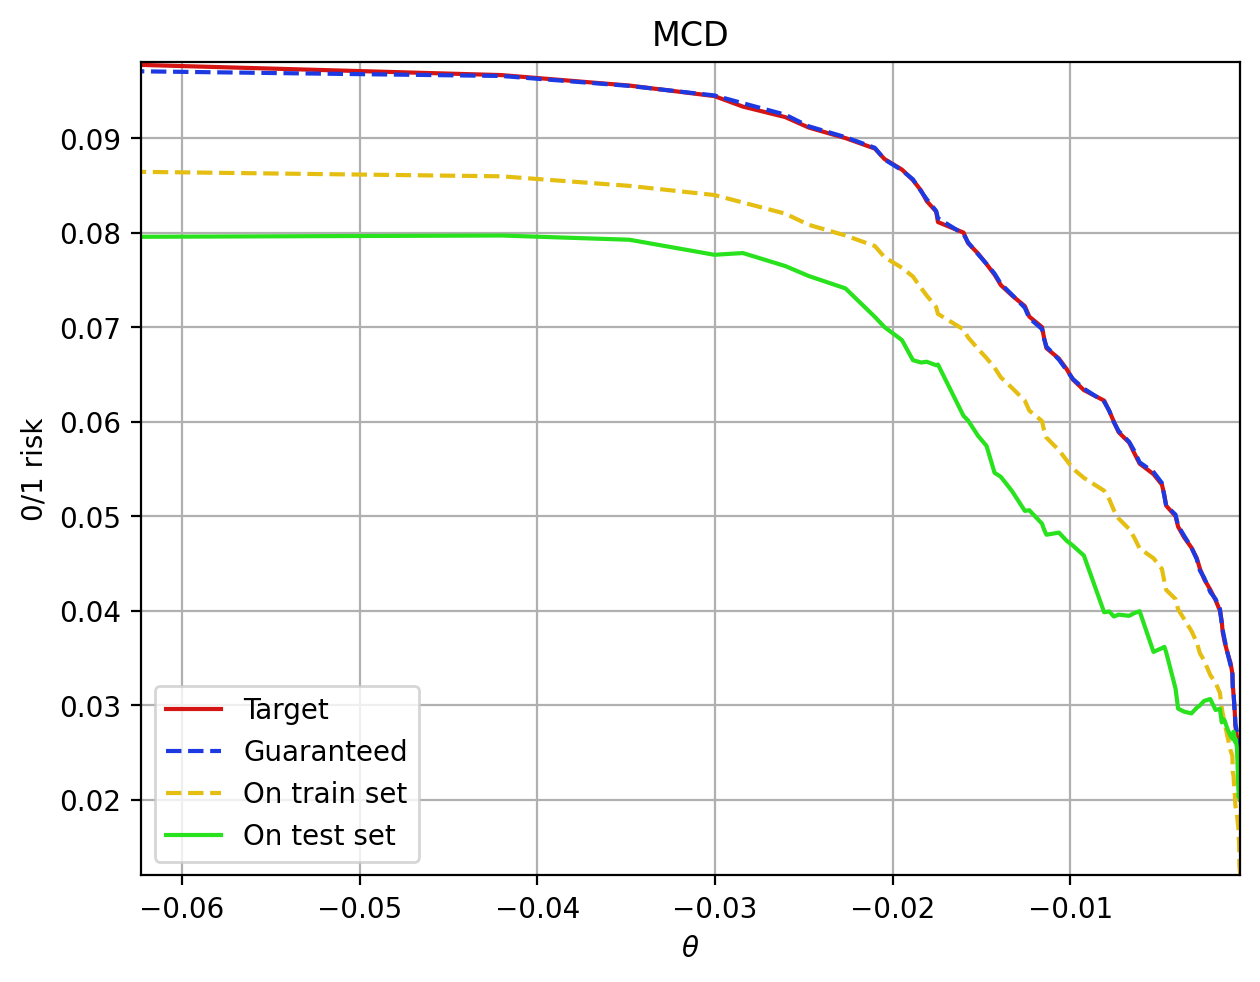

In [10]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

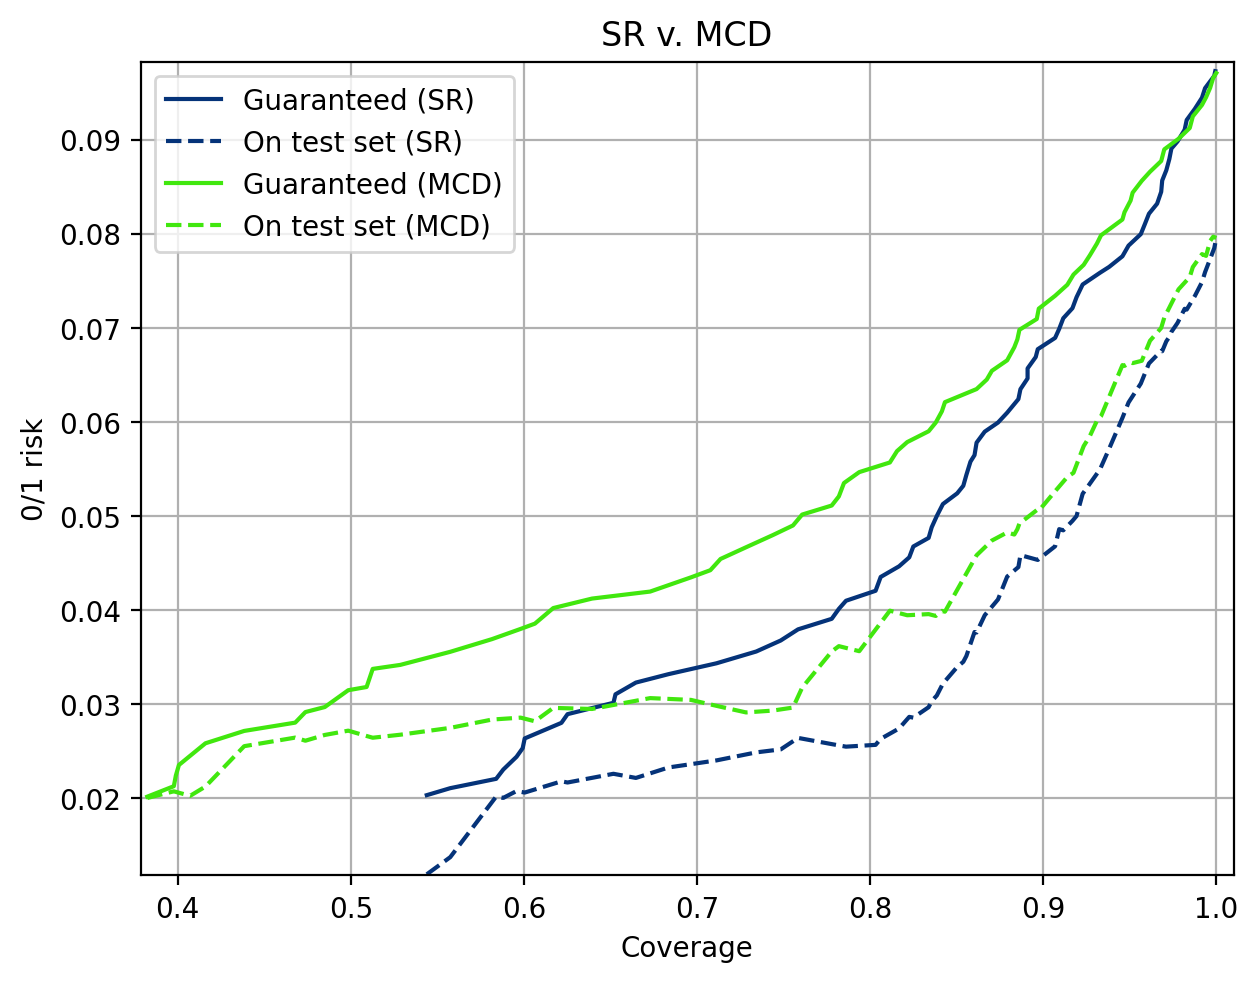

In [11]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

## <font color = 'yellow'> 2. __FPP/FNP__
Dichotomy search for upper bound

### <font color = 'orange'> 2.1. __FPP__

In [12]:
metric_targets = np.linspace(0.001,0.12,num=num_targets)

In [13]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR, k=int(np.log2(train_set_SR.shape[0])),
                            delta=delta, metric_targets=metric_targets, 
                            metric='FP', mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD, k=int(np.log2(train_set_MCD.shape[0])),
                             delta=delta, metric_targets=metric_targets,
                             metric='FP', mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

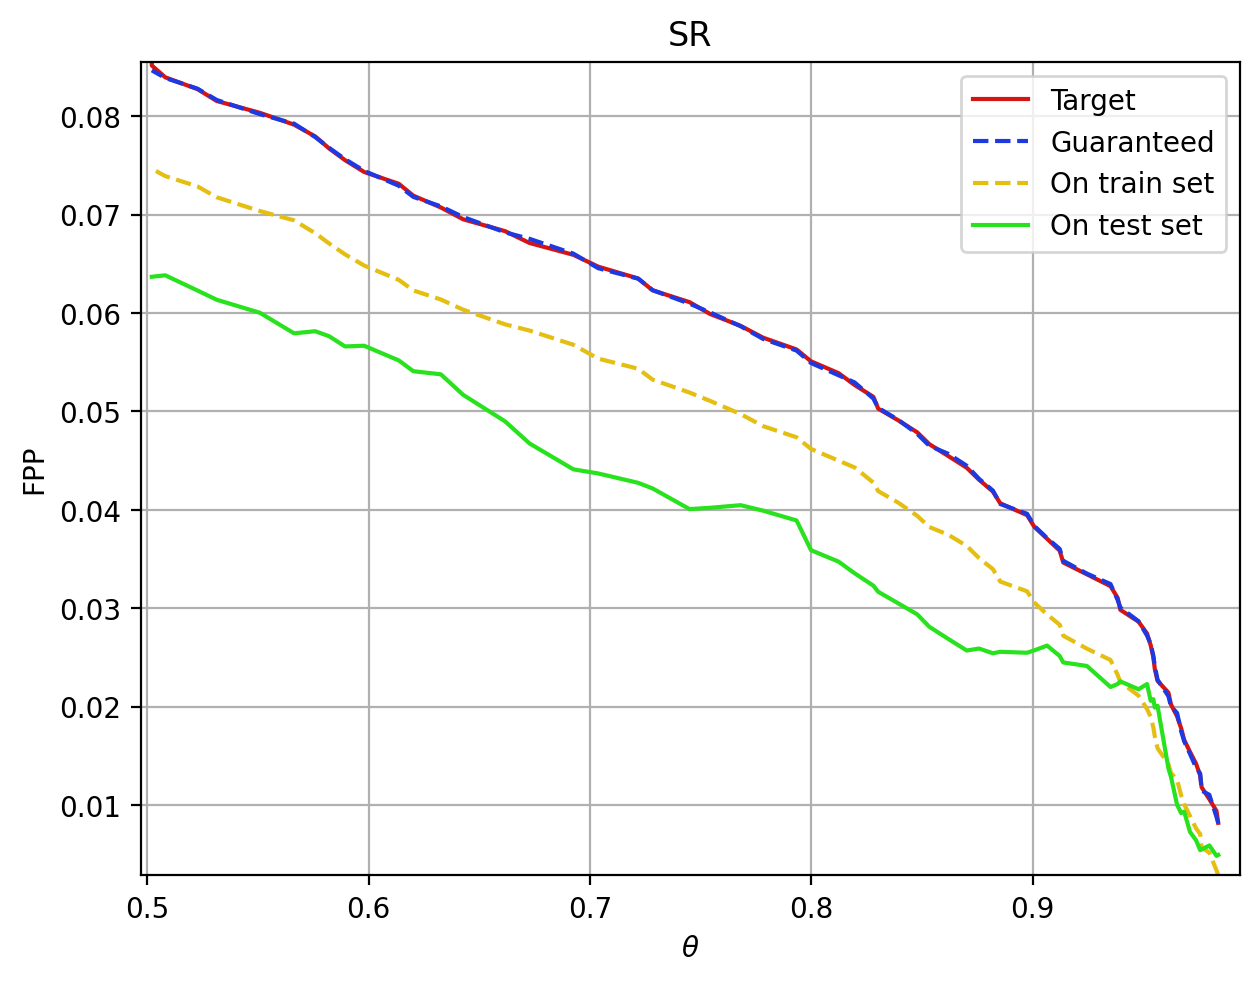

In [14]:
metric_plots(all_results, metric='FPP', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(min(results_SR.test_metric), min(results_SR.train_metric)), 1.01*max(results_SR.metric_bound)],
             title='SR')

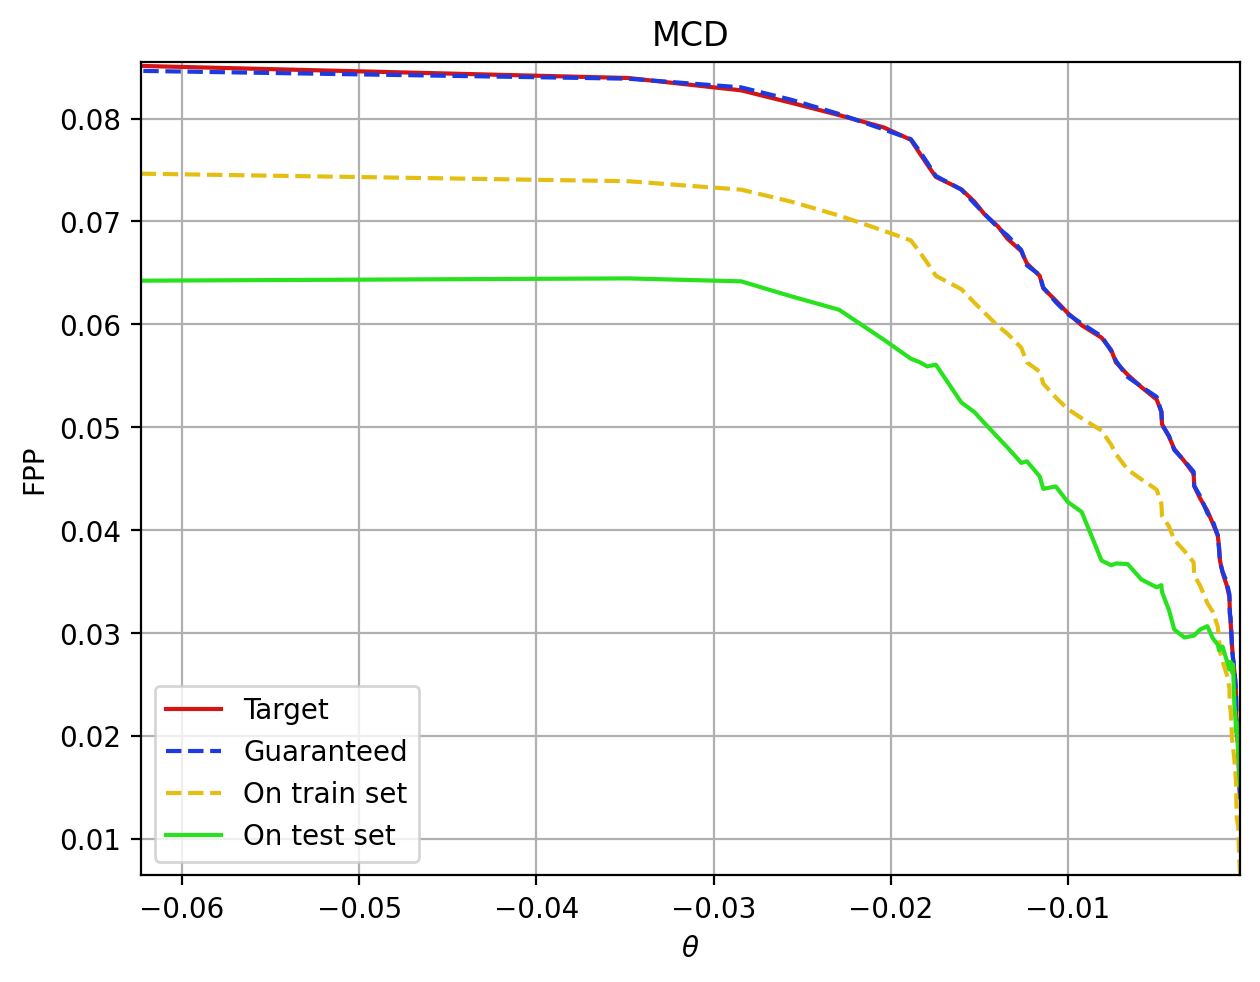

In [15]:
metric_plots(all_results, metric='FPP', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_MCD.train_metric)), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

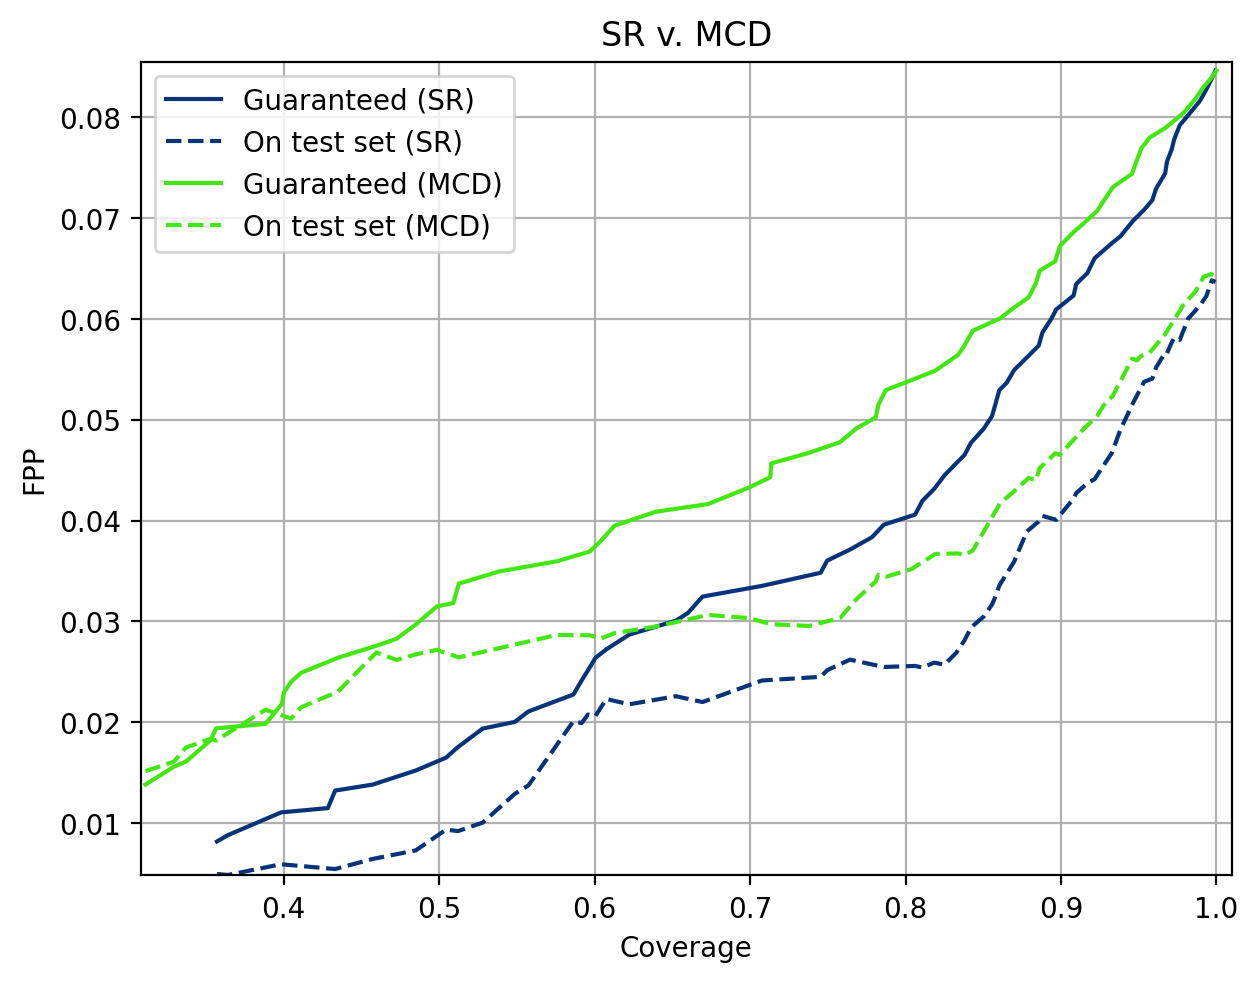

In [16]:
metric_plots(all_results, metric='FPP', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 2.2. __FNP__

In [17]:
metric_targets = np.linspace(0.0001,0.02,num=num_targets)

In [18]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR, k=int(np.log2(train_set_SR.shape[0])),
                            delta=delta, metric_targets=metric_targets, 
                            metric='FN', mode='dicho')
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD, k=int(np.log2(train_set_MCD.shape[0])),
                             delta=delta, metric_targets=metric_targets,
                             metric='FN', mode='dicho')
all_results = {'SR': results_SR,
               'MCD': results_MCD}

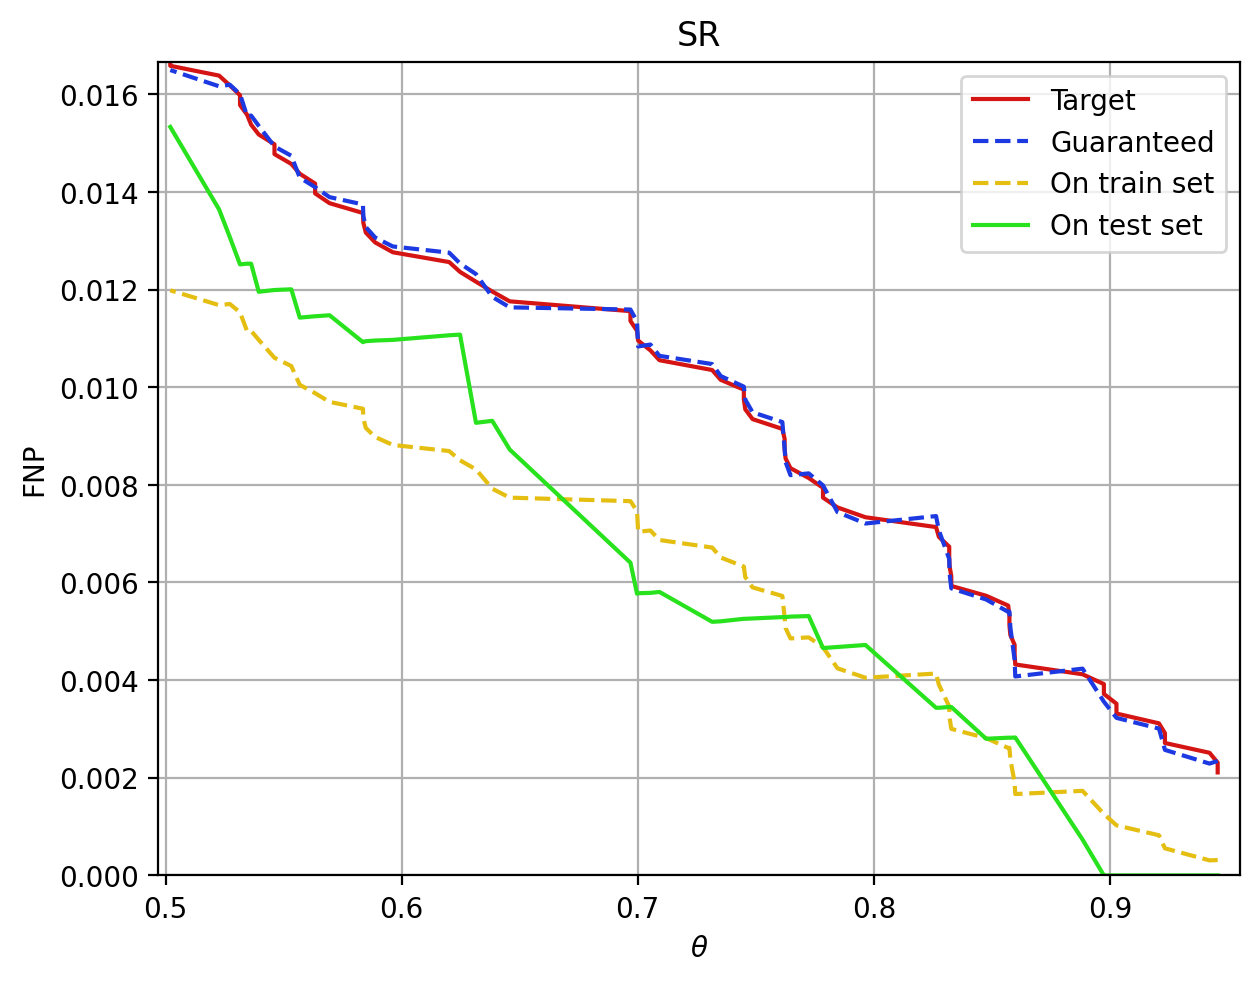

In [19]:
metric_plots(all_results, metric='FNP', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

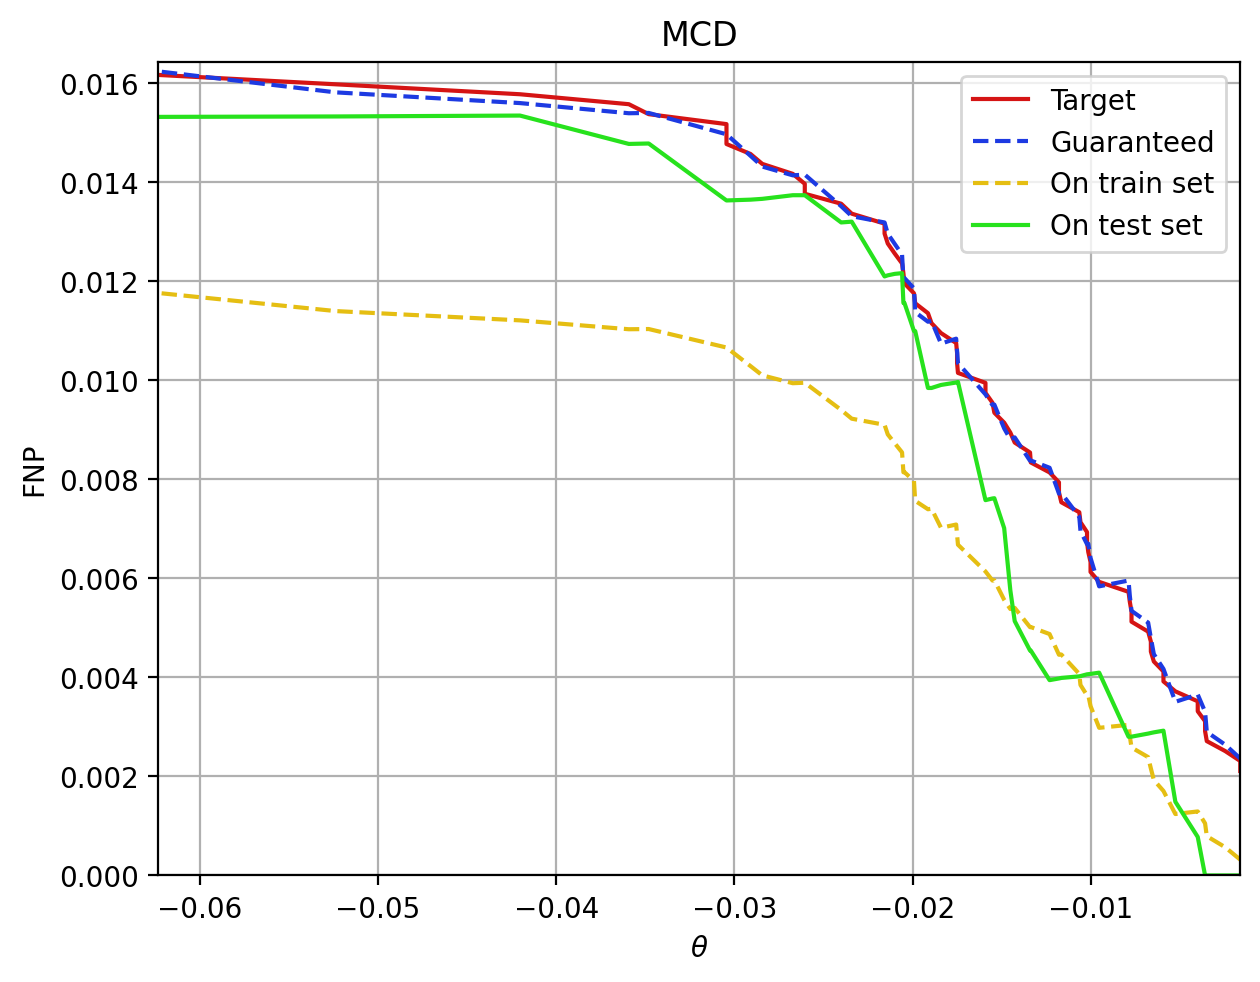

In [20]:
metric_plots(all_results, metric='FNP', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

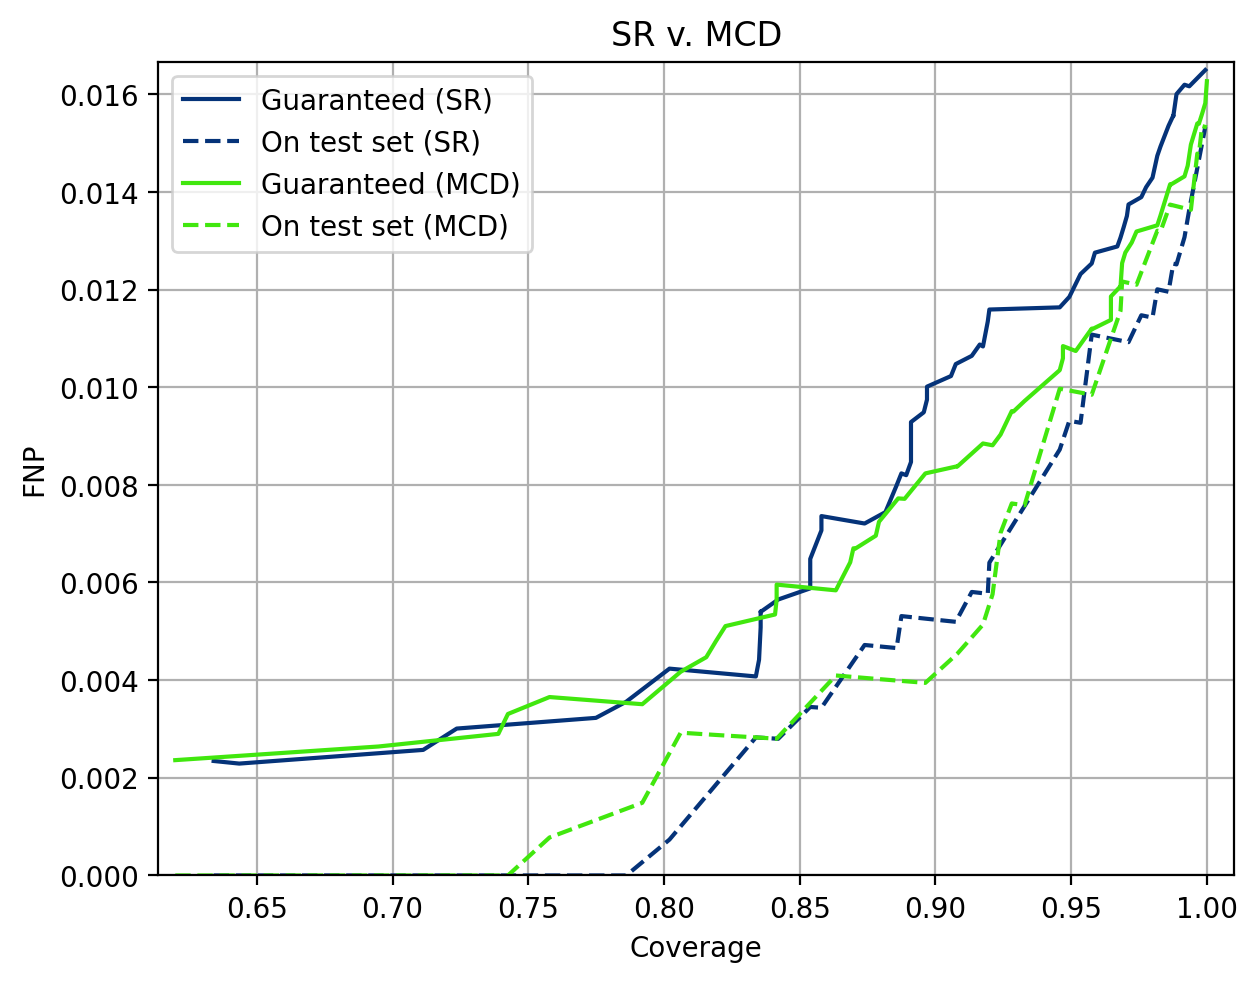

In [21]:
metric_plots(all_results, metric='FNP', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

## <font color = 'yellow'> __3. Conditional metrics__

### <font color = 'orange'> 3.1. __FPR__

In [22]:
metric_targets = np.linspace(0.001,0.2,num=num_targets)

In [23]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='FPR', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='FPR', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

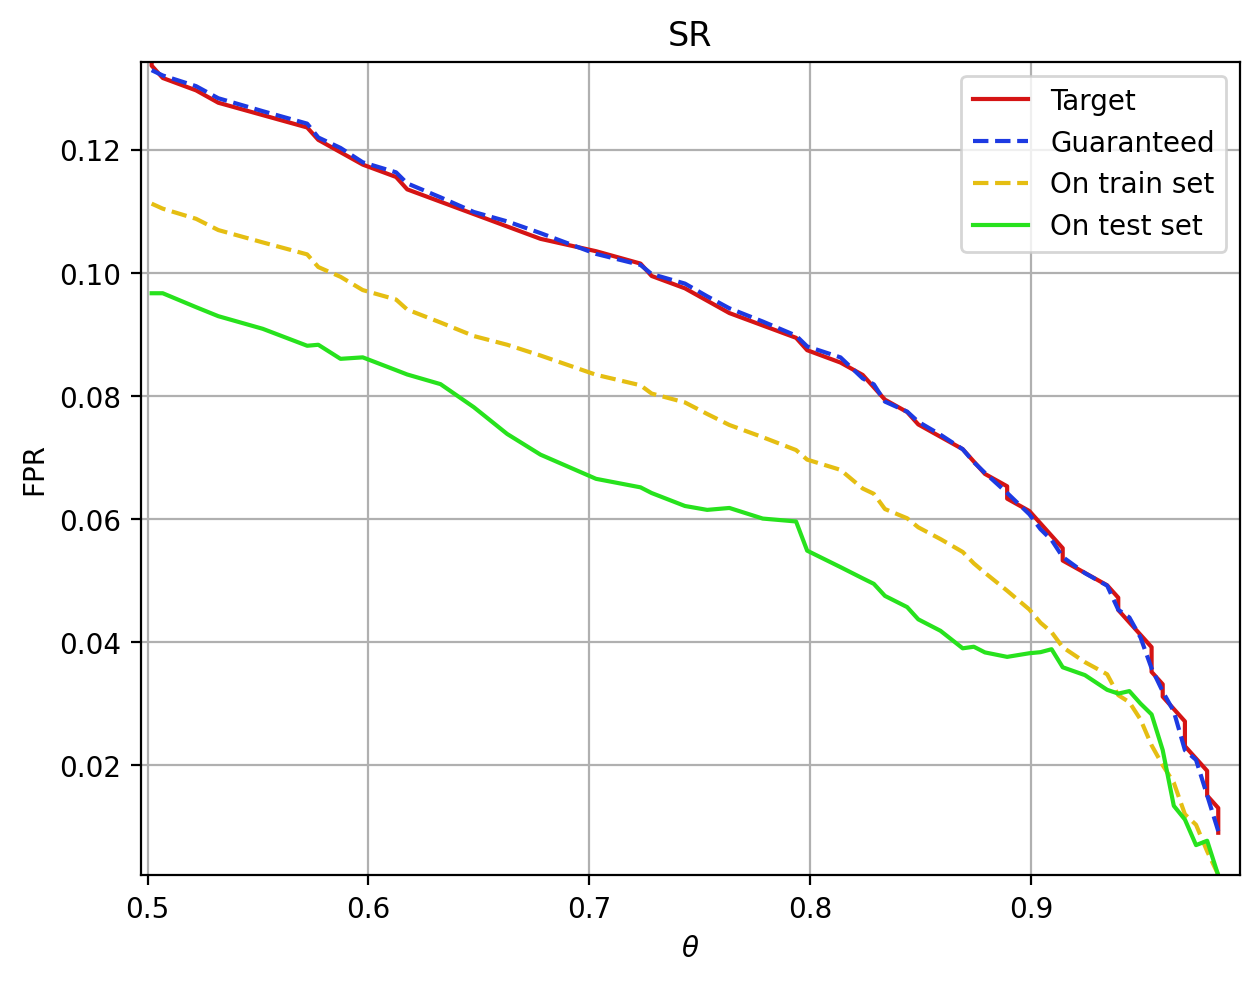

In [24]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

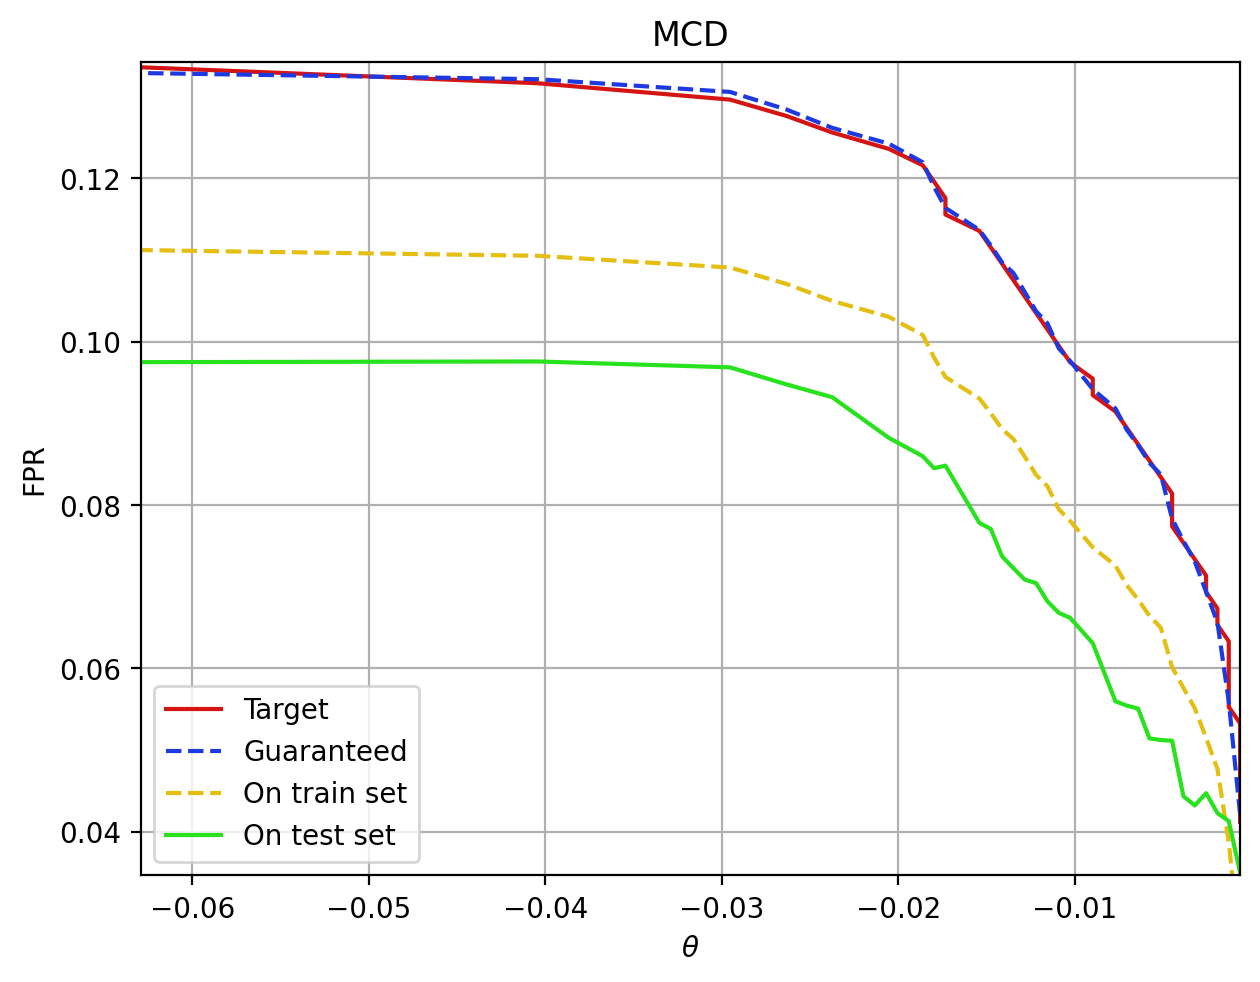

In [25]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

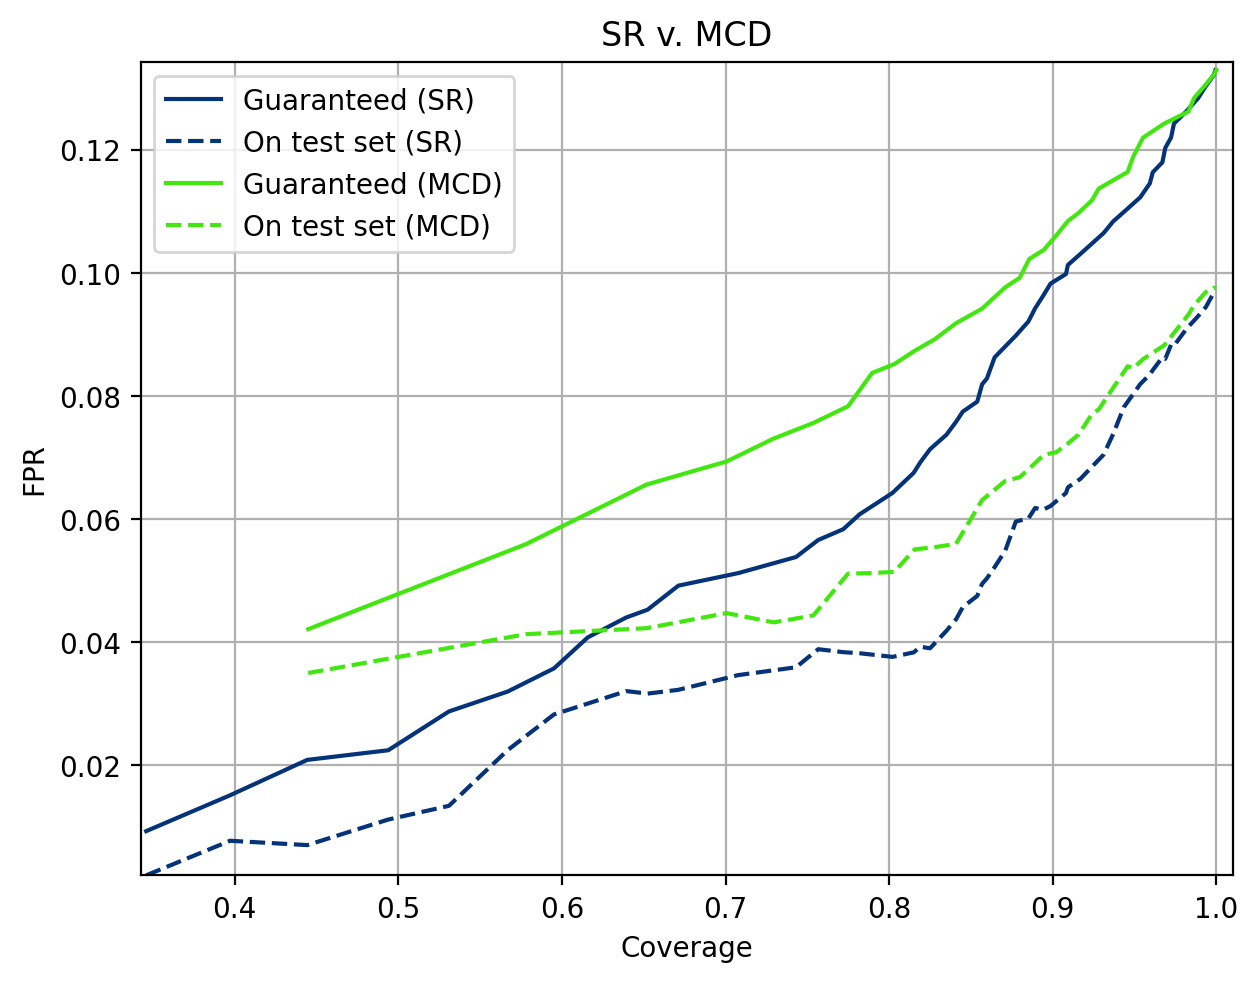

In [26]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 3.2. __FNR__

In [27]:
metric_targets = np.linspace(0.001,0.05,num=num_targets)

In [28]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='FNR', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='FNR', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

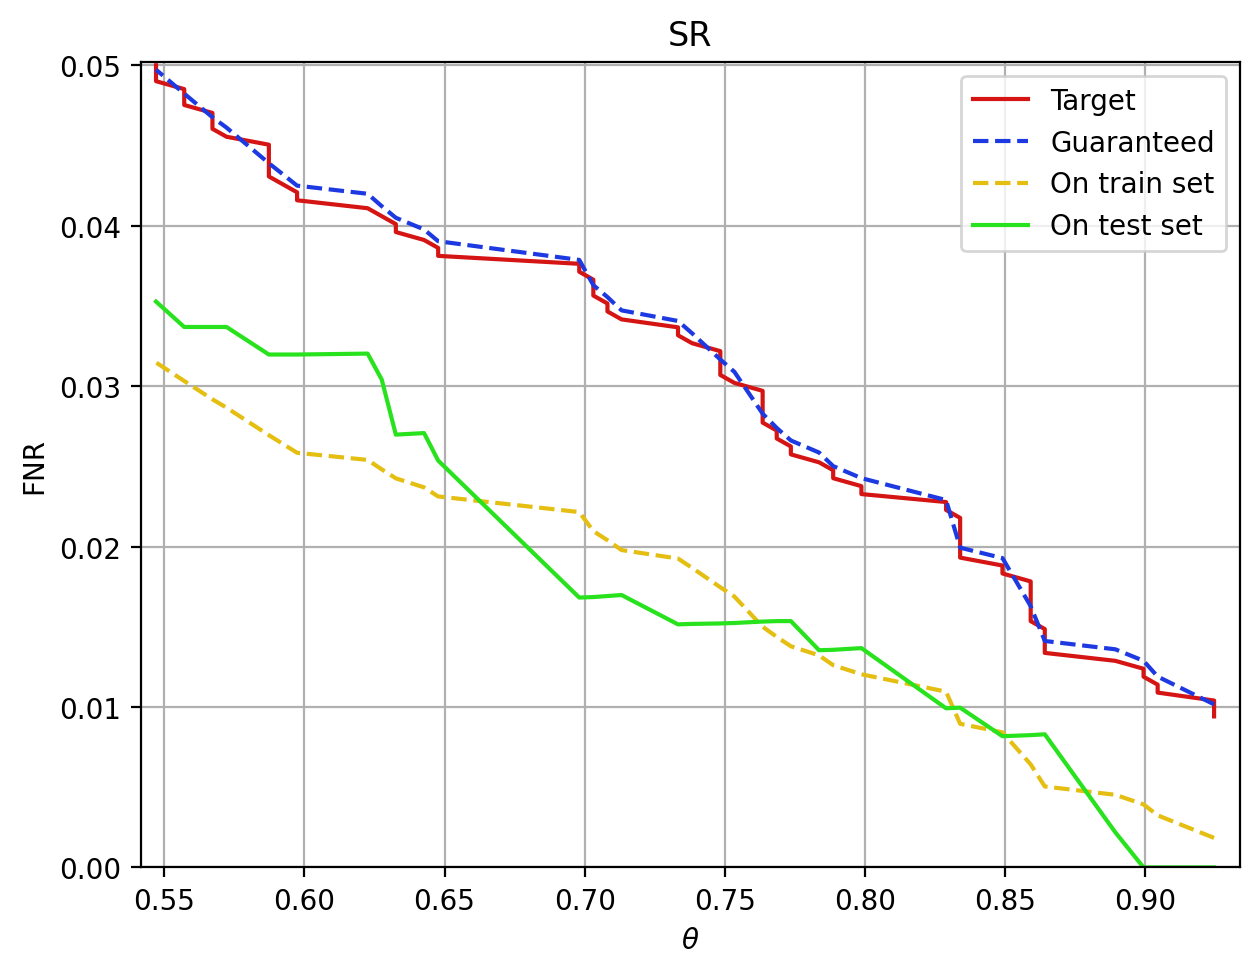

In [29]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.test_metric), 1.01*max(results_SR.metric_bound)],
             title='SR')

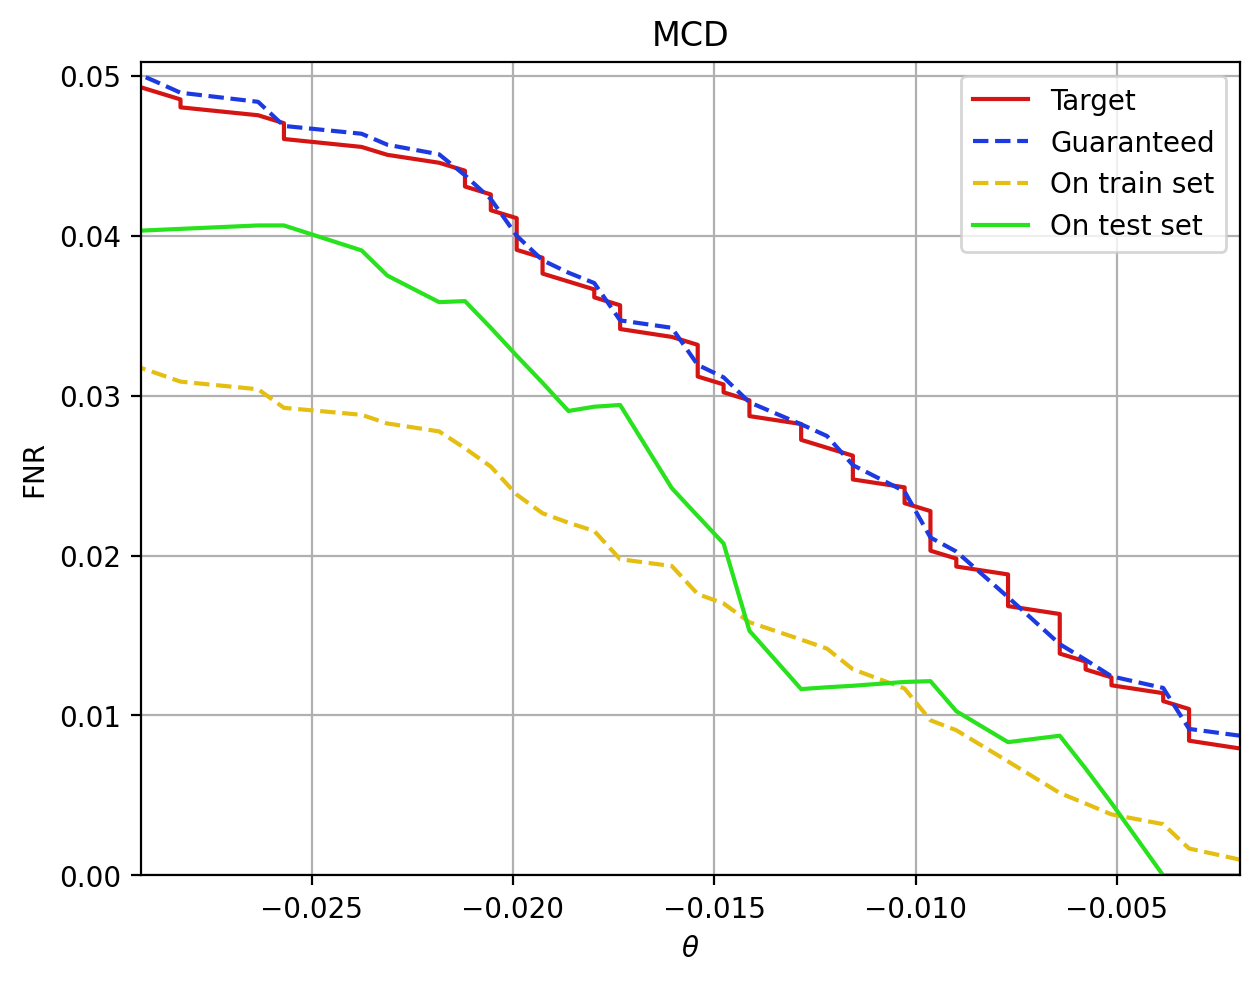

In [30]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.test_metric), 1.01*max(results_MCD.metric_bound)],
             title='MCD')

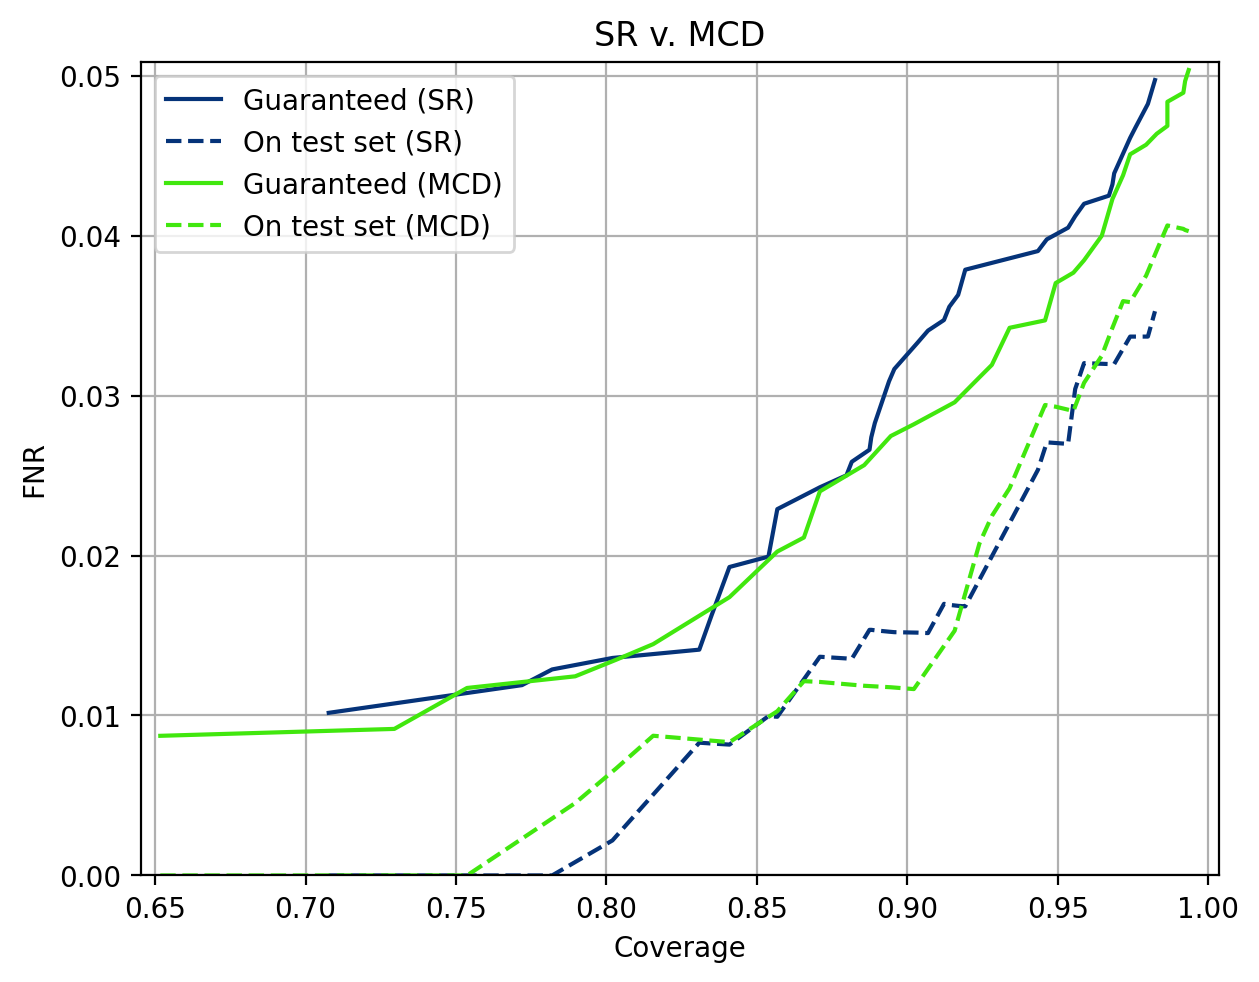

In [31]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_MCD.test_coverage),max(results_SR.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.test_metric), min(results_SR.test_metric)), 
                   1.01*max(max(results_MCD.metric_bound),max(results_SR.metric_bound))],
             title='SR v. MCD')

### <font color = 'orange'> 3.3. __PPV__

In [32]:
metric_targets = np.linspace(0.65,0.99,num=num_targets)

In [33]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='PPV', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='PPV', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

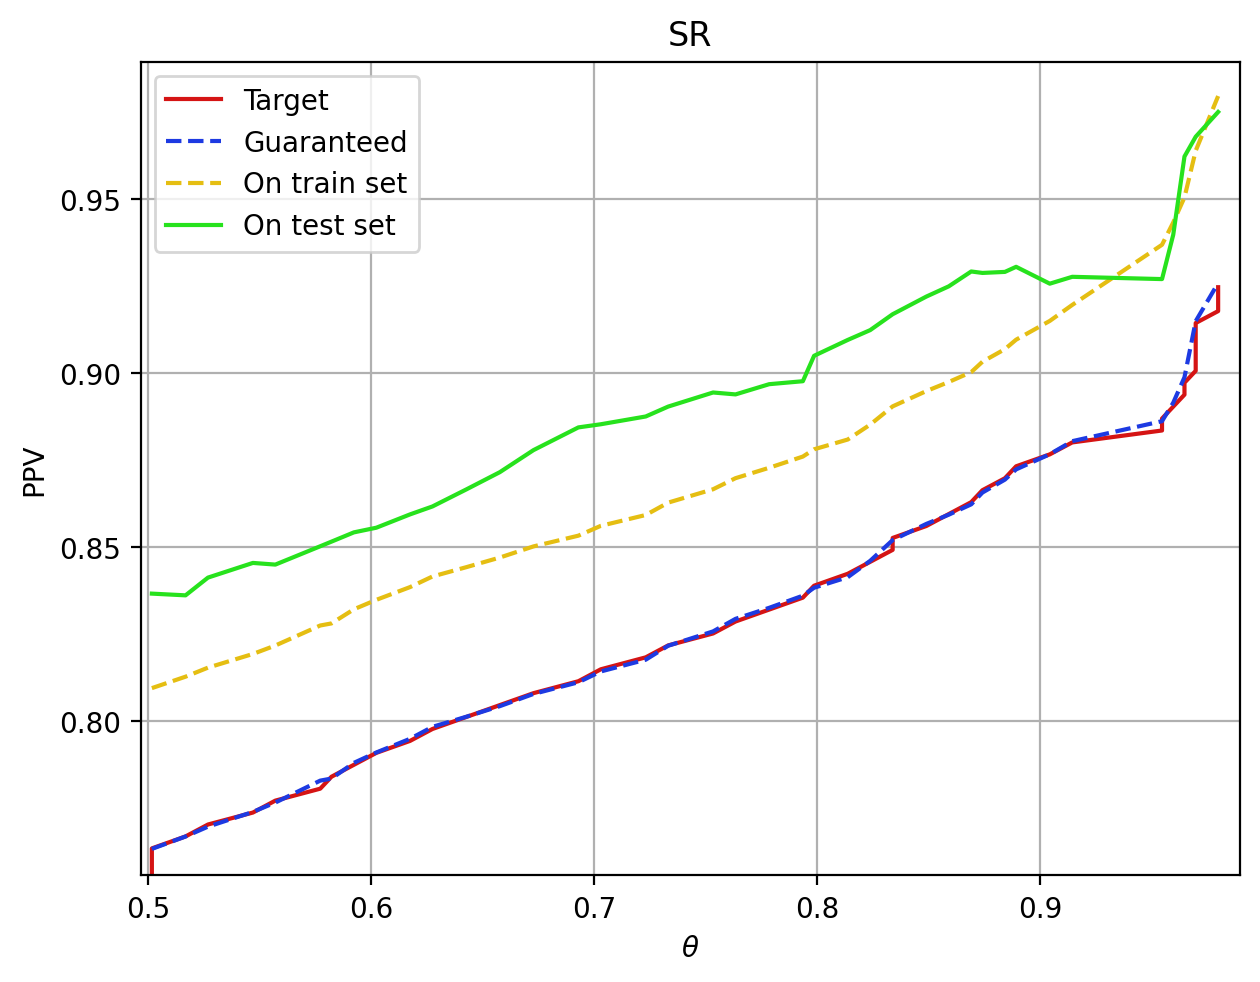

In [34]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

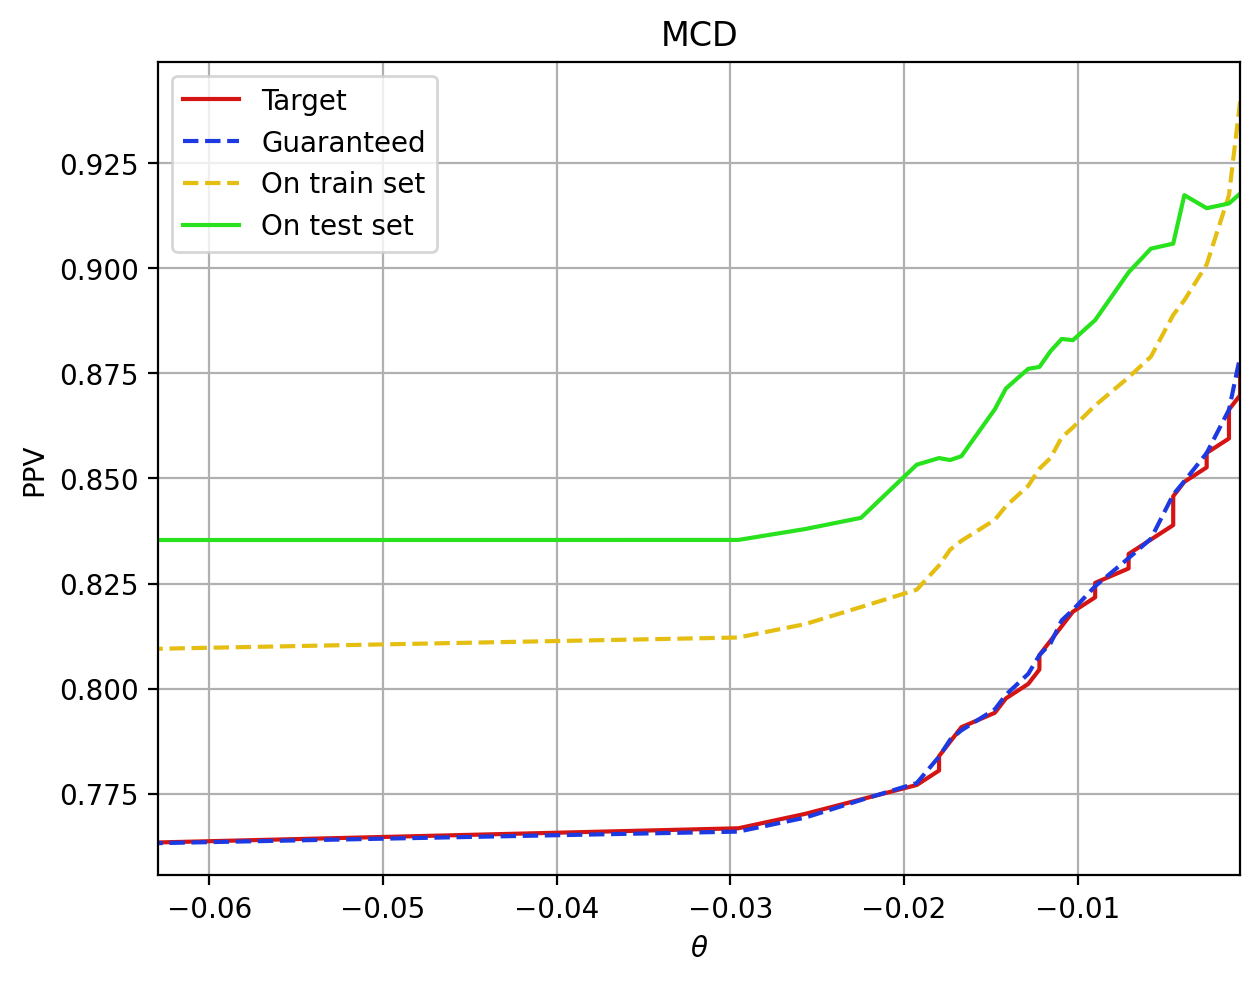

In [35]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

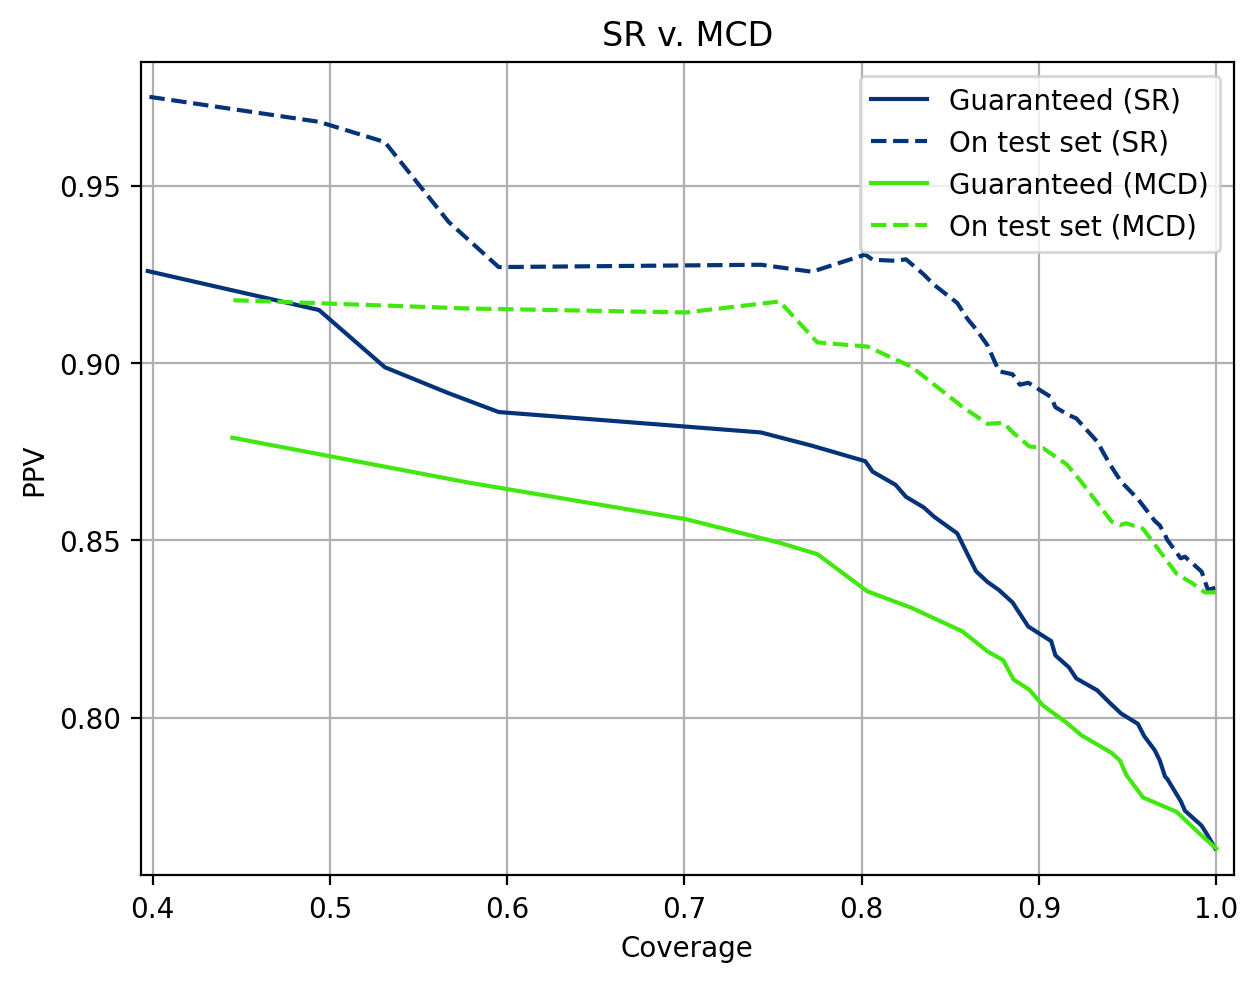

In [36]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')

### <font color = 'orange'> 3.4. __SE__

In [37]:
metric_targets = np.linspace(0.95,0.999,num=num_targets)

In [38]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='SE', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='SE', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

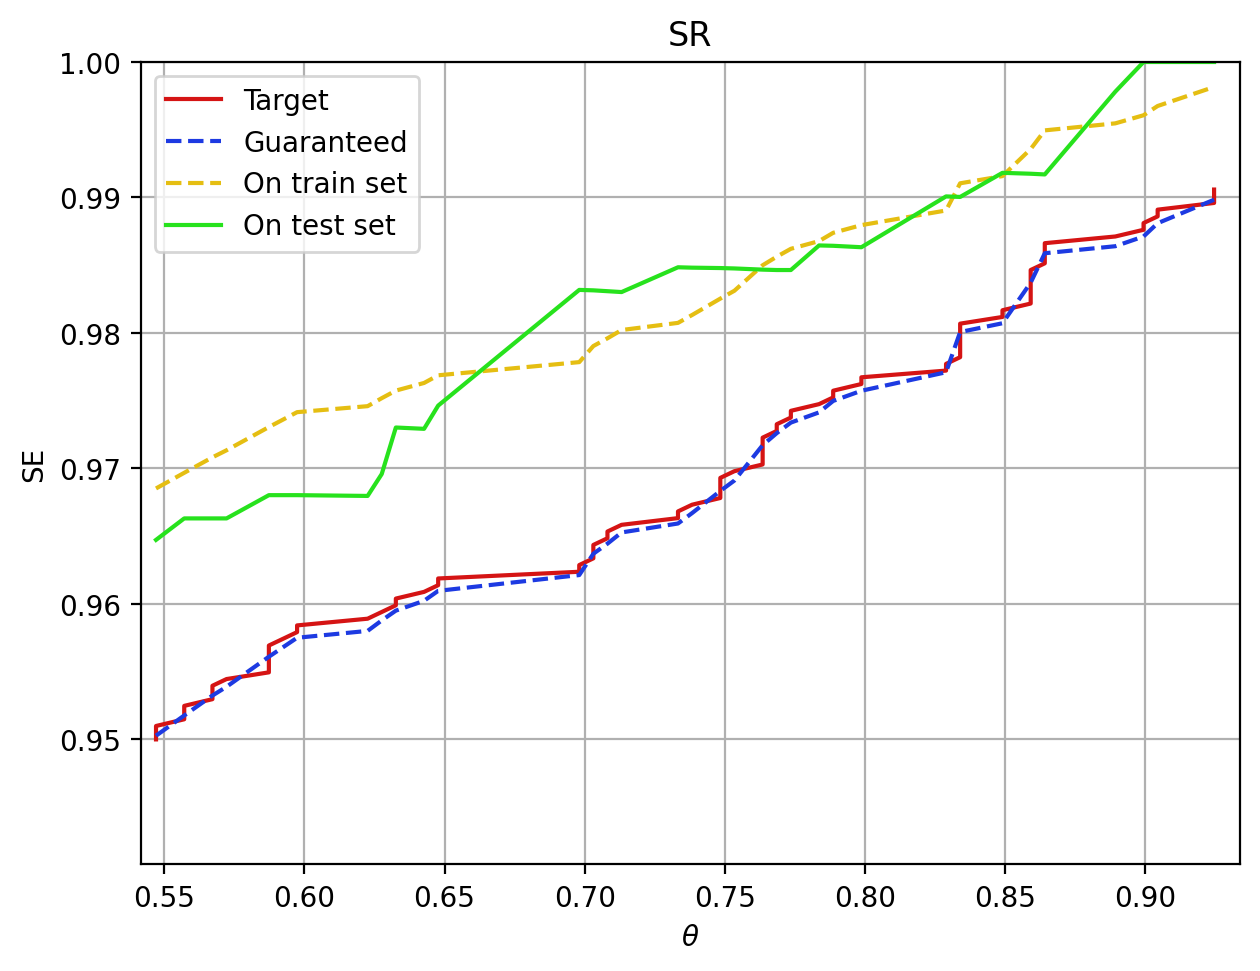

In [39]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

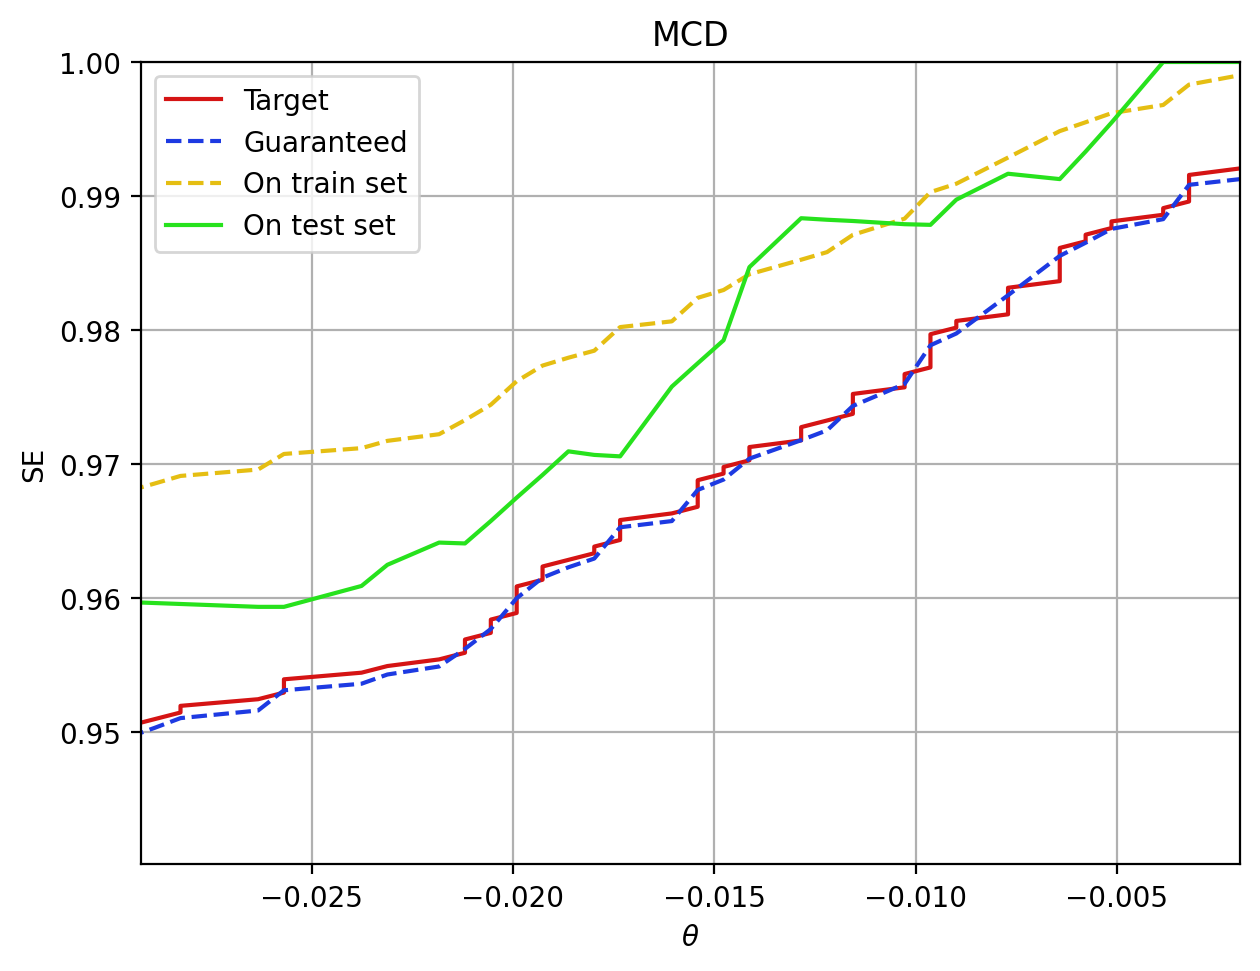

In [40]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

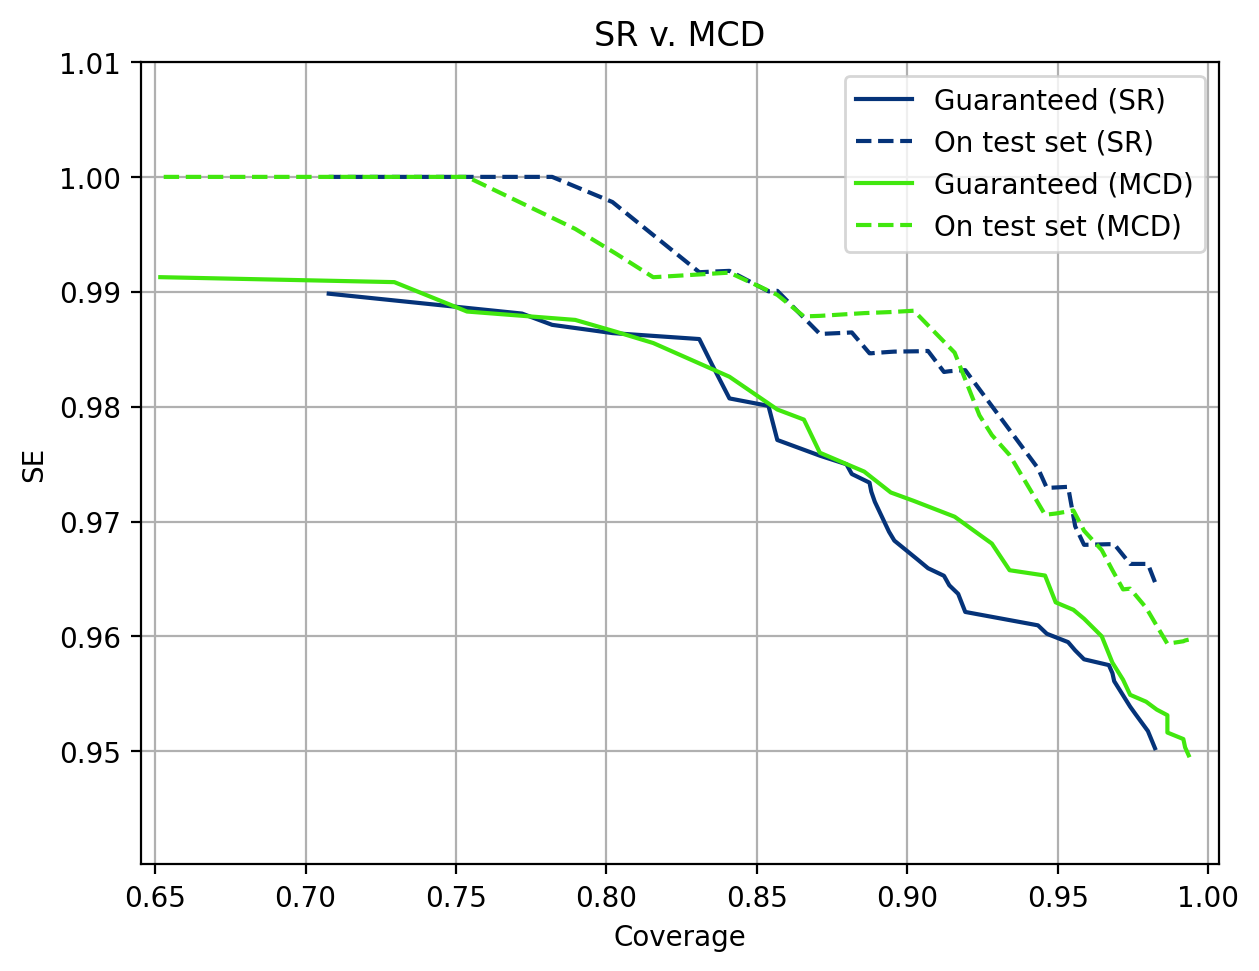

In [41]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')

### <font color = 'orange'> 3.5. __SP__

In [42]:
metric_targets = np.linspace(0.8,0.999,num=num_targets)

In [43]:
results_SR = sgp_at_targets(train_set_SR, test_set_SR,
                            delta=delta, metric_targets=metric_targets, 
                            metric='SP', mode='greedy', steps=greedy_search_steps_num)
results_MCD = sgp_at_targets(train_set_MCD, test_set_MCD,
                             delta=delta, metric_targets=metric_targets,
                             metric='SP', mode='greedy', steps=greedy_search_steps_num)
all_results = {'SR': results_SR,
               'MCD': results_MCD}

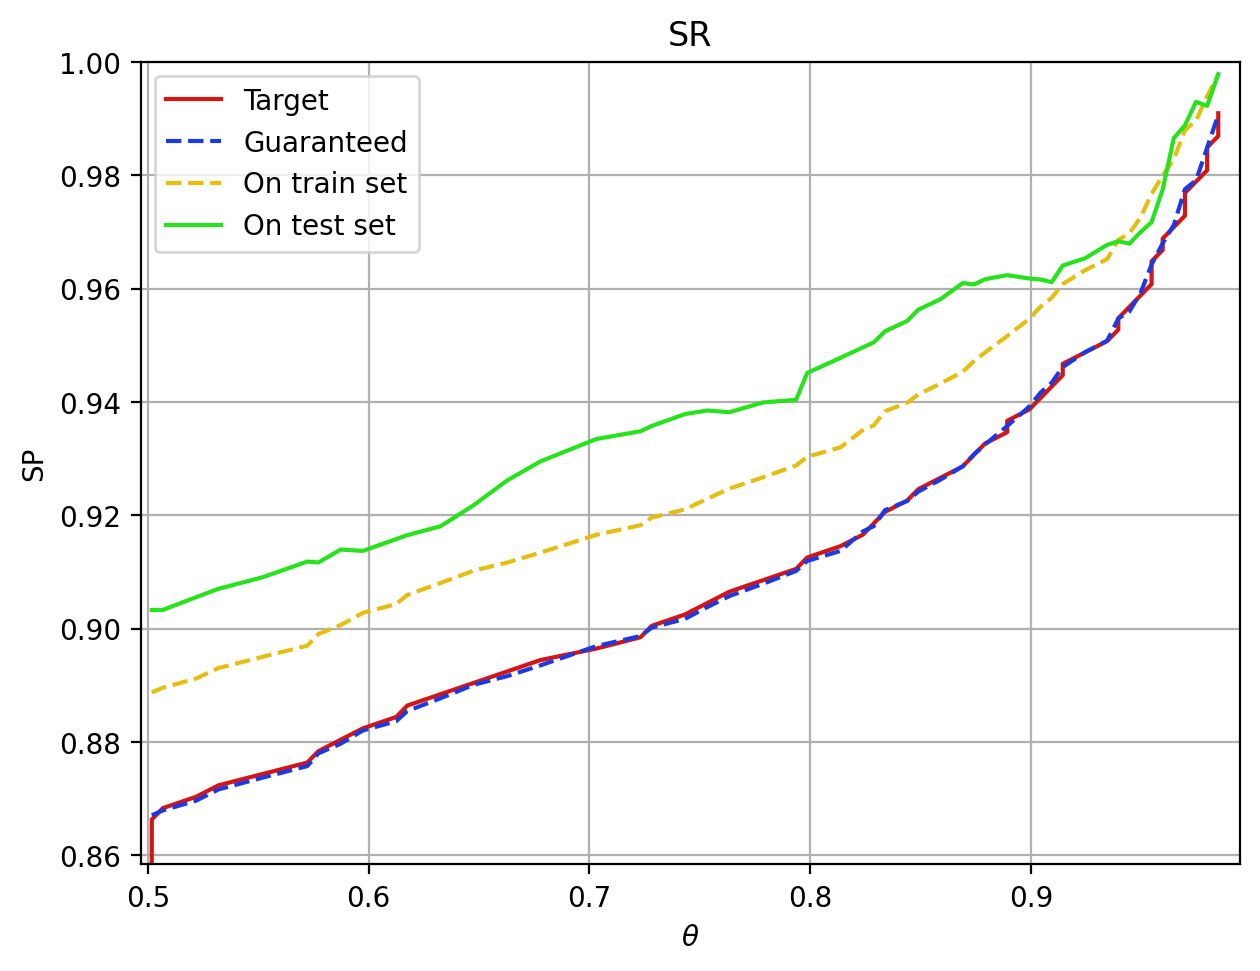

In [44]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_1_SR,
             xlim=[0.99*min(results_SR.theta_star),1.01*max(results_SR.theta_star)], 
             ylim=[0.99*min(results_SR.metric_bound), 
                   min(1,1.01*max(max(results_SR.test_metric),max(results_SR.train_metric)))],
             title='SR')

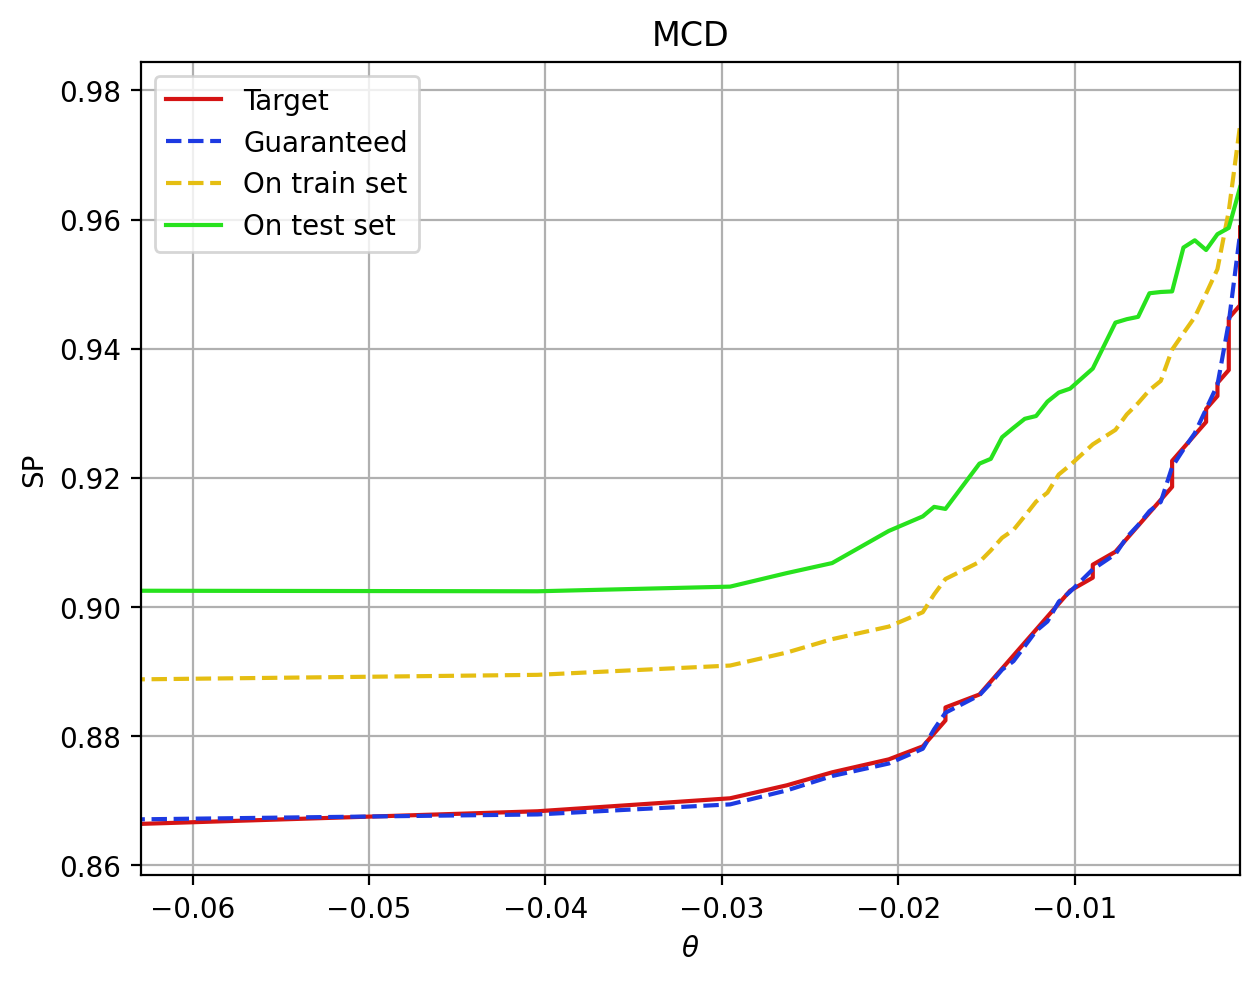

In [45]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_1_MCD,
             xlim=[0.99*min(results_MCD.theta_star),1.01*max(results_MCD.theta_star)], 
             ylim=[0.99*min(results_MCD.metric_bound), 
                   min(1,1.01*max(max(results_MCD.test_metric),max(results_MCD.train_metric)))],
             title='MCD')

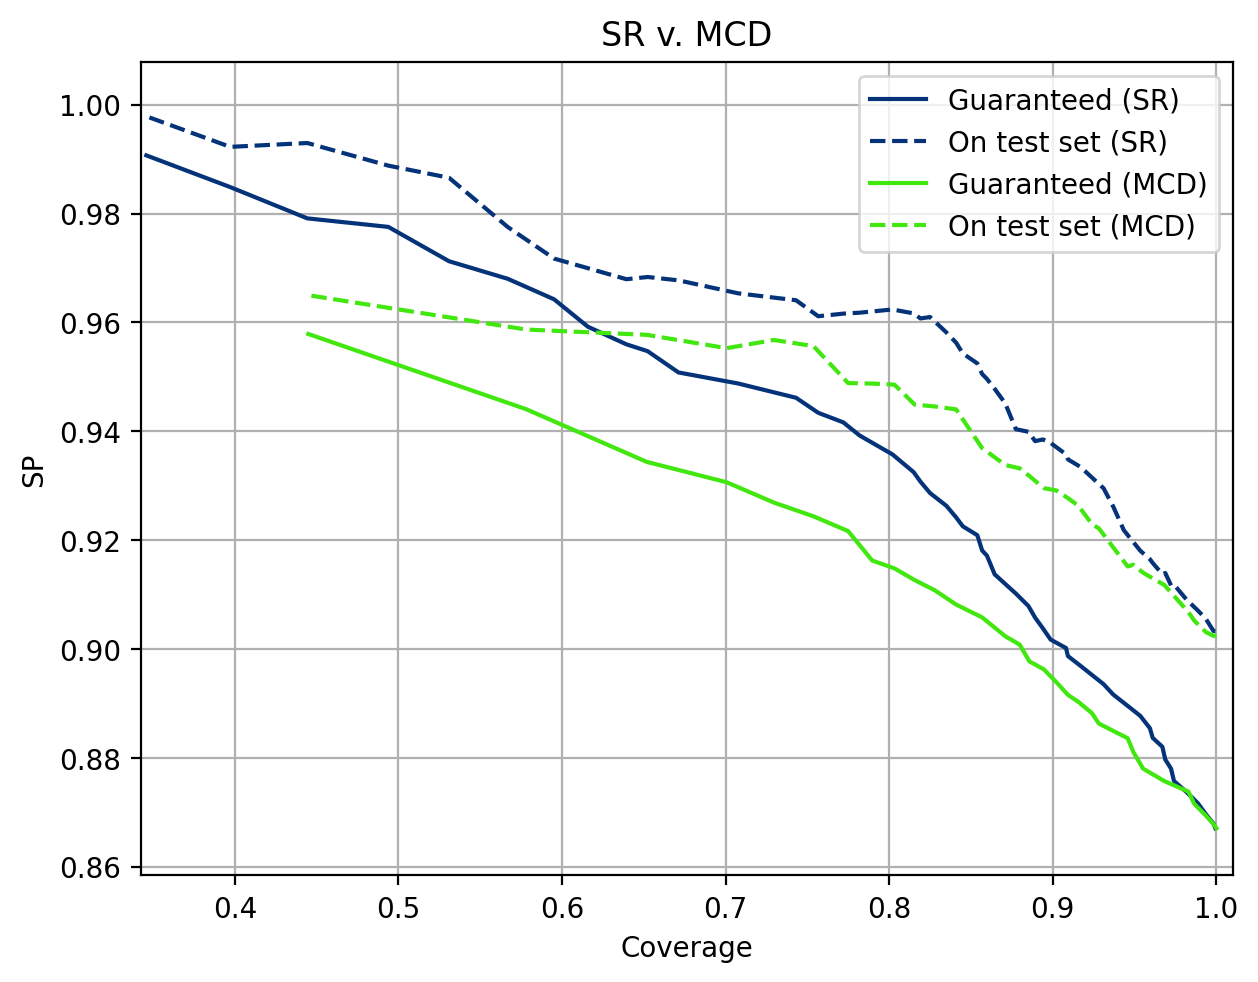

In [46]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_2,
             xlim=[0.99*min(min(results_SR.test_coverage),min(results_MCD.test_coverage)),
                   1.01*max(max(results_SR.test_coverage),max(results_MCD.test_coverage))], 
             ylim=[0.99*min(min(results_MCD.metric_bound), min(results_SR.metric_bound)), 
                   1.01*max(max(results_MCD.test_metric),max(results_SR.test_metric))],
             title='SR v. MCD')